In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

In [44]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Remove ID column
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Convert target
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# One Hot Encoding
df = pd.get_dummies(df, drop_first=True)

print(df.head())
print(df.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

/tmp/ipykernel_9989/565009869.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [45]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (needed for SVM and KNN)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)

X_train shape : (5634, 30)
X_test shape  : (1409, 30)


In [46]:
def evaluate_regression(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)


def classification_metrics(y_true, y_pred, y_score, model_name):

    print(f"\n========== {model_name} ==========")

    print("Accuracy :", accuracy_score(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    auc = roc_auc_score(y_true, y_score)
    print("ROC-AUC Score :", auc)

    fpr, tpr, _ = roc_curve(y_true, y_score)

    return fpr, tpr, auc


Linear Regression
MAE : 0.29097722419683003
MSE : 0.13409956305380902
RMSE: 0.3661960718710798
R2  : 0.31106101359366045

========== Linear Regression ==========
Accuracy : 0.8225691980127751

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.70      0.57      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.81      0.82      0.82      1409



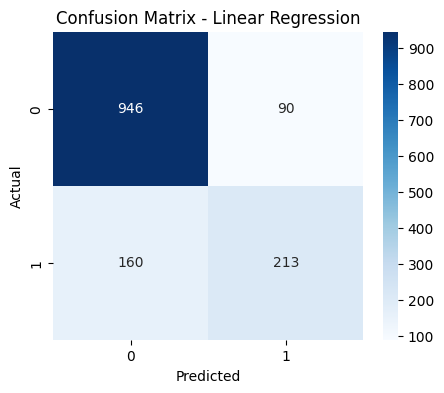

ROC-AUC Score : 0.8563807488070222


In [47]:
# LINEAR REGRESSION

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Regression metrics
evaluate_regression(y_test, y_pred_lr, "Linear Regression")

# Convert to class labels
y_pred_lr_class = (y_pred_lr >= 0.5).astype(int)

# Classification metrics
fpr_lr, tpr_lr, auc_lr = classification_metrics(
    y_test,
    y_pred_lr_class,
    y_pred_lr,
    "Linear Regression"
)


Decision Tree Regression
MAE : 0.29548142890939205
MSE : 0.29496885103698445
RMSE: 0.5431103488583001
R2  : -0.5154079299521654

========== Decision Tree ==========
Accuracy : 0.7047551454932577

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1036
           1       0.44      0.45      0.45       373

    accuracy                           0.70      1409
   macro avg       0.62      0.62      0.62      1409
weighted avg       0.71      0.70      0.71      1409



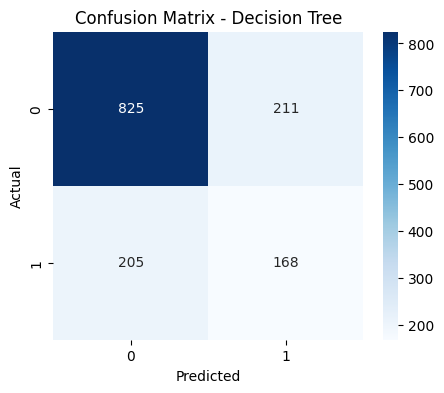

ROC-AUC Score : 0.6230462078317307

Best Decision Tree Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [48]:
# DECISION TREE REGRESSION + TUNING

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# Regression metrics
evaluate_regression(y_test, y_pred_dt, "Decision Tree Regression")

# Convert to class labels
y_pred_dt_class = (y_pred_dt >= 0.5).astype(int)

# Classification metrics
fpr_dt, tpr_dt, auc_dt = classification_metrics(
    y_test,
    y_pred_dt_class,
    y_pred_dt,
    "Decision Tree"
)

# Tuning

param_grid = {
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Decision Tree Parameters:")
print(grid.best_params_)


Random Forest Regression
MAE : 0.2739833553009564
MSE : 0.14482390865793915
RMSE: 0.3805573657912026
R2  : 0.25596448962202

========== Random Forest ==========
Accuracy : 0.7828246983676366

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.63      0.45      0.52       373

    accuracy                           0.78      1409
   macro avg       0.72      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409



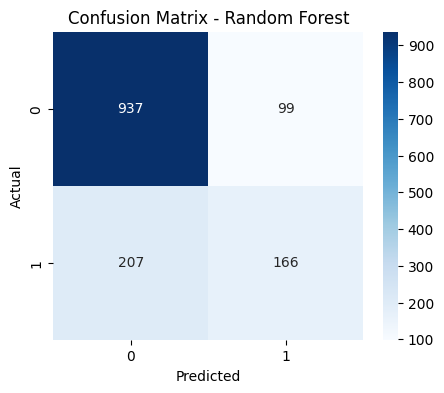

ROC-AUC Score : 0.8202718229527881

Best Random Forest Parameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [49]:
# RANDOM FOREST + TUNING

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Regression metrics
evaluate_regression(y_test, y_pred_rf, "Random Forest Regression")

# Convert to class labels
y_pred_rf_class = (y_pred_rf >= 0.5).astype(int)

# Classification metrics
fpr_rf, tpr_rf, auc_rf = classification_metrics(
    y_test,
    y_pred_rf_class,
    y_pred_rf,
    "Random Forest"
)

#Tuning

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(grid.best_params_)


Best SVM Parameters:
{'C': 0.1, 'kernel': 'linear'}

========== SVM ==========
Accuracy : 0.8211497515968772

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



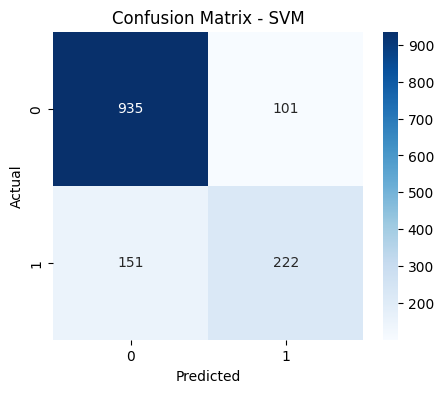

ROC-AUC Score : 0.8527047729460598


In [39]:
# SUPPORT VECTOR MACHINE (SVM)
svm = SVC(probability=True)

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_svm = grid.best_estimator_

print("\nBest SVM Parameters:")
print(grid.best_params_)

# Predictions
y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

# Classification metrics
fpr_svm, tpr_svm, auc_svm = classification_metrics(
    y_test,
    y_pred_svm,
    y_prob_svm,
    "SVM"
)


Best KNN Parameters:
{'n_neighbors': 9, 'weights': 'uniform'}

========== KNN ==========
Accuracy : 0.7934705464868701

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1036
           1       0.62      0.55      0.59       373

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.79      0.79      0.79      1409



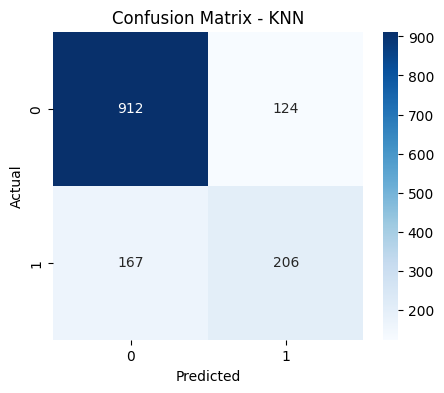

ROC-AUC Score : 0.824997153415384


In [40]:
# K-NEAREST NEIGHBORS (KNN)
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_knn = grid.best_estimator_

print("\nBest KNN Parameters:")
print(grid.best_params_)

# Predictions
y_pred_knn = best_knn.predict(X_test_scaled)
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

# Classification metrics
fpr_knn, tpr_knn, auc_knn = classification_metrics(
    y_test,
    y_pred_knn,
    y_prob_knn,
    "KNN"
)

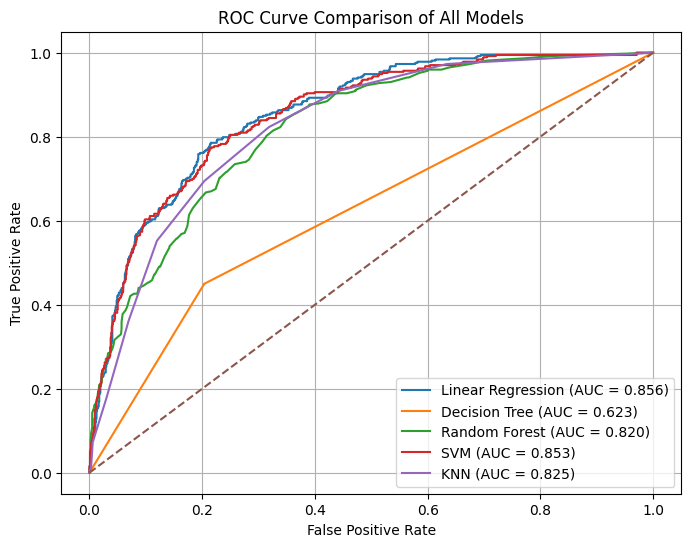

In [41]:
# ROC CURVE COMPARISON (ALL MODELS)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Linear Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.3f})")

# Random guess line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of All Models")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],

    "ROC-AUC Score": [
        auc_lr,
        auc_dt,
        auc_rf,
        auc_svm,
        auc_knn
    ]
})

print(results.sort_values(by="ROC-AUC Score", ascending=False))

               Model  ROC-AUC Score
0  Linear Regression       0.856381
3                SVM       0.852705
4                KNN       0.824997
2      Random Forest       0.820272
1      Decision Tree       0.623046


In [50]:
best_model = results.sort_values(
    by="ROC-AUC Score",
    ascending=False
).iloc[0]

print("Best Model Selected:")
print(best_model)

print("""
JUSTIFICATION:

The best model was selected based on highest ROC-AUC score.

ROC-AUC is important because:
1. It measures ability to separate churn vs non-churn customers.
2. It works well even when classes are imbalanced.
3. Higher AUC means better classification quality.

This model also showed strong overall predictive performance
compared with other algorithms.
""")

Best Model Selected:
Model            Linear Regression
ROC-AUC Score             0.856381
Name: 0, dtype: object

JUSTIFICATION:

The best model was selected based on highest ROC-AUC score.

ROC-AUC is important because:
1. It measures ability to separate churn vs non-churn customers.
2. It works well even when classes are imbalanced.
3. Higher AUC means better classification quality.

This model also showed strong overall predictive performance
compared with other algorithms.



Top 10 Important Features:
TotalCharges                      0.205994
tenure                            0.201273
MonthlyCharges                    0.193970
InternetService_Fiber optic       0.099293
PaymentMethod_Electronic check    0.025065
PaperlessBilling_Yes              0.024187
gender_Male                       0.022982
Partner_Yes                       0.020476
Dependents_Yes                    0.018883
SeniorCitizen                     0.018857
dtype: float64


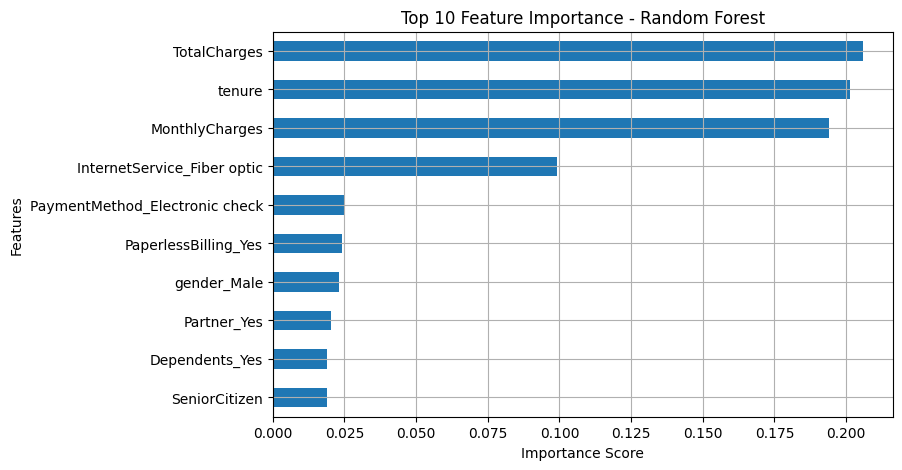

In [51]:
importances = pd.Series(rf.feature_importances_, index=X.columns)

top10 = importances.sort_values(ascending=False).head(10)

print("Top 10 Important Features:")
print(top10)

plt.figure(figsize=(8,5))
top10.sort_values().plot(kind='barh')

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(True)
plt.show()